[*********************100%***********************]  1 of 1 completed

Datos descargados:


,USD_MXN
Date,
2010-01-01,13.0681
2010-01-04,12.8718
2010-01-05,12.8108
2010-01-06,12.7395
2010-01-07,12.7602


USD_MXN    float64
dtype: object
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0097
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 7.9980e-04
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 7.8921e-04
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 6.8092e-04
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 6.7219e-04
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 6.2128e-04
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 6.1903e-04
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 5.4262e-04
Epoch 9/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 5.3129e-04
Epoch 10/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 5.4389e-04
Epoch 11/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 4.8108e-04
Epoch 12/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 5.0608e-04
Epoch 13/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 4.6290e-04
Epoch 14/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 4.7622e-04


,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.091943,0.130899,0.987828
1,Random Forest,0.121749,0.158199,0.982222
2,XGBoost,0.119331,0.155402,0.982845
3,LSTM,0.180024,0.246960,0.957260


Mejor modelo: Regresión Lineal


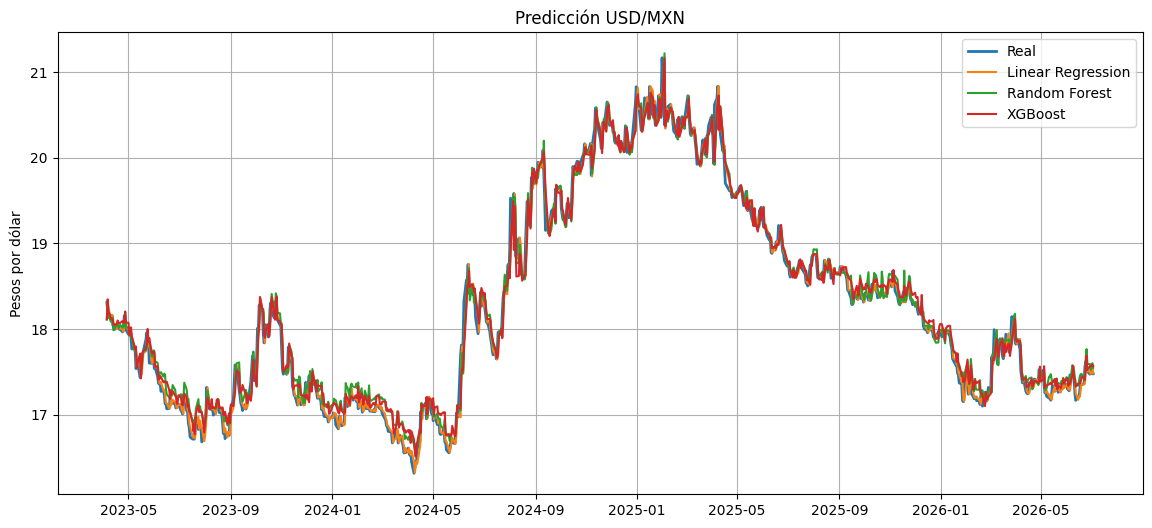

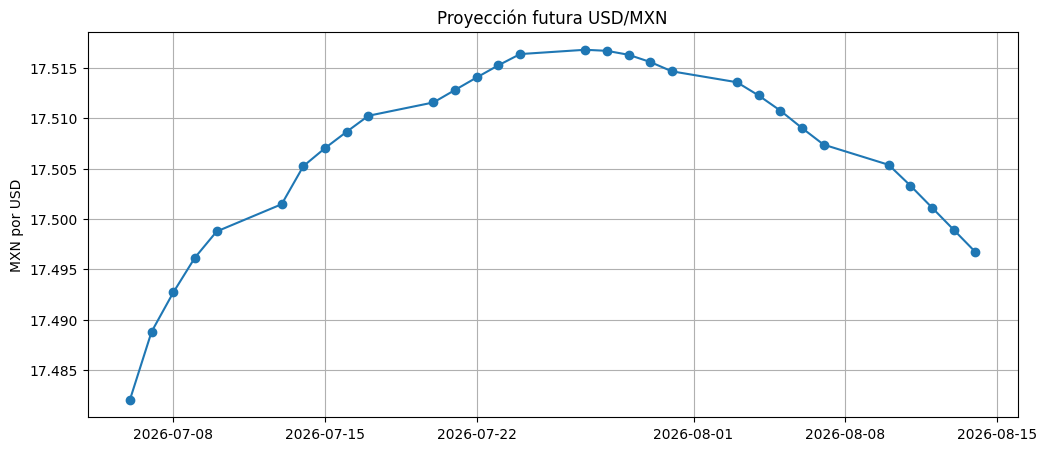

Predicción a 30 días hábiles
USD/MXN esperado: $17.4967


In [3]:
# ==========================================
# PROYECTO 4:
# Predicción Tipo de Cambio USD/MXN
# Machine Learning + Deep Learning
# ==========================================

!pip install yfinance xgboost tensorflow -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


# ==========================================
# 1. Parámetros
# ==========================================

ticker = "MXN=X"

fecha_inicio = "2010-01-01"
fecha_fin = datetime.today().strftime("%Y-%m-%d")

dias_prediccion = 30


# ==========================================
# 2. Descargar información Yahoo Finance
# ==========================================

datos = yf.download(
    ticker,
    start=fecha_inicio,
    end=fecha_fin,
    auto_adjust=True
)


# Corregir MultiIndex de Yahoo
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)


df = datos[["Close"]].copy()

df.columns = ["USD_MXN"]

df["USD_MXN"] = pd.to_numeric(
    df["USD_MXN"],
    errors="coerce"
)

df.dropna(inplace=True)


print("Datos descargados:")

display(df.head())

print(df.dtypes)


# ==========================================
# 3. Crear variables financieras
# ==========================================

def crear_variables(data):

    data = data.copy()

    data["Return"] = (
        data["USD_MXN"]
        .pct_change()
    )

    data["MA_7"] = (
        data["USD_MXN"]
        .rolling(7)
        .mean()
    )

    data["MA_30"] = (
        data["USD_MXN"]
        .rolling(30)
        .mean()
    )

    data["MA_90"] = (
        data["USD_MXN"]
        .rolling(90)
        .mean()
    )


    data["Volatility"] = (
        data["Return"]
        .rolling(30)
        .std()
    )


    data["Lag_1"] = (
        data["USD_MXN"]
        .shift(1)
    )


    data["Lag_7"] = (
        data["USD_MXN"]
        .shift(7)
    )


    data["Lag_30"] = (
        data["USD_MXN"]
        .shift(30)
    )


    return data


df = crear_variables(df)


df["Target"] = (
    df["USD_MXN"]
    .shift(-1)
)


df.dropna(inplace=True)



features = [

    "USD_MXN",
    "Return",
    "MA_7",
    "MA_30",
    "MA_90",
    "Volatility",
    "Lag_1",
    "Lag_7",
    "Lag_30"

]


# Conversión definitiva a float

df[features] = (
    df[features]
    .astype(float)
)

df["Target"] = (
    df["Target"]
    .astype(float)
)



X = df[features]

y = df["Target"]



# ==========================================
# 4. División temporal
# ==========================================


split = int(
    len(df)*0.8
)


X_train = X.iloc[:split]

X_test = X.iloc[split:]


y_train = y.iloc[:split]

y_test = y.iloc[split:]


fechas_test = df.index[split:]



# ==========================================
# 5. Machine Learning
# ==========================================


modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)


pred_lr = modelo_lr.predict(
    X_test
)



modelo_rf = RandomForestRegressor(

    n_estimators=300,
    max_depth=10,
    random_state=42

)


modelo_rf.fit(
    X_train,
    y_train
)


pred_rf = modelo_rf.predict(
    X_test
)



modelo_xgb = XGBRegressor(

    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42,
    objective="reg:squarederror"

)



modelo_xgb.fit(
    X_train,
    y_train
)


pred_xgb = modelo_xgb.predict(
    X_test
)



# ==========================================
# 6. LSTM
# ==========================================


scaler = MinMaxScaler()


serie = scaler.fit_transform(
    df[["USD_MXN"]]
)



ventana = 60


X_lstm = []

y_lstm = []



for i in range(
    ventana,
    len(serie)
):

    X_lstm.append(
        serie[i-ventana:i,0]
    )


    y_lstm.append(
        serie[i,0]
    )



X_lstm=np.array(
    X_lstm
)


y_lstm=np.array(
    y_lstm
)



X_lstm = X_lstm.reshape(

    X_lstm.shape[0],
    X_lstm.shape[1],
    1

)



split_lstm = int(
    len(X_lstm)*0.8
)



modelo_lstm = Sequential()


modelo_lstm.add(

    LSTM(
        64,
        return_sequences=True,
        input_shape=(ventana,1)
    )

)


modelo_lstm.add(
    Dropout(0.2)
)



modelo_lstm.add(

    LSTM(32)

)



modelo_lstm.add(

    Dense(1)

)



modelo_lstm.compile(

    optimizer="adam",
    loss="mse"

)



modelo_lstm.fit(

    X_lstm[:split_lstm],
    y_lstm[:split_lstm],
    epochs=20,
    batch_size=32,
    verbose=1

)



pred_lstm = modelo_lstm.predict(

    X_lstm[split_lstm:]

)



pred_lstm = scaler.inverse_transform(

    pred_lstm

)


real_lstm = scaler.inverse_transform(

    y_lstm[split_lstm:]
    .reshape(-1,1)

)



# ==========================================
# 7. Evaluación
# ==========================================


def evaluar(nombre,real,pred):

    return {

        "Modelo":nombre,

        "MAE":mean_absolute_error(
            real,
            pred
        ),

        "RMSE":np.sqrt(
            mean_squared_error(
                real,
                pred
            )
        ),

        "R2":r2_score(
            real,
            pred
        )

    }



resultados = pd.DataFrame([


    evaluar(
        "Regresión Lineal",
        y_test,
        pred_lr
    ),


    evaluar(
        "Random Forest",
        y_test,
        pred_rf
    ),


    evaluar(
        "XGBoost",
        y_test,
        pred_xgb
    ),


    evaluar(
        "LSTM",
        real_lstm,
        pred_lstm
    )

])


display(resultados)



# Selección automática mejor modelo ML

mejor = (
    resultados
    .iloc[:3]
    .sort_values("RMSE")
    .iloc[0]["Modelo"]
)


if mejor=="Regresión Lineal":

    modelo_final=modelo_lr


elif mejor=="Random Forest":

    modelo_final=modelo_rf


else:

    modelo_final=modelo_xgb



print(
    "Mejor modelo:",
    mejor
)



# ==========================================
# 8. Comparación gráfica
# ==========================================


plt.figure(
    figsize=(14,6)
)


plt.plot(

    fechas_test,
    y_test,
    label="Real",
    linewidth=2

)



plt.plot(

    fechas_test,
    pred_lr,
    label="Linear Regression"

)



plt.plot(

    fechas_test,
    pred_rf,
    label="Random Forest"

)



plt.plot(

    fechas_test,
    pred_xgb,
    label="XGBoost"

)



plt.title(
    "Predicción USD/MXN"
)


plt.ylabel(
    "Pesos por dólar"
)


plt.legend()

plt.grid()

plt.show()



# ==========================================
# 9. Predicción futura
# ==========================================


df_futuro = df.copy()


predicciones = []



fechas_futuras = pd.bdate_range(

    start=df.index[-1],

    periods=dias_prediccion+1

)[1:]



for fecha in fechas_futuras:


    ultimo = df_futuro.iloc[-1]


    entrada = pd.DataFrame(
        [ultimo[features]]
    )


    pred = modelo_final.predict(
        entrada
    )[0]


    predicciones.append(
        pred
    )


    nueva = ultimo.copy()


    nueva["USD_MXN"] = pred


    df_futuro.loc[fecha] = nueva


    df_futuro = crear_variables(
        df_futuro
    )


# ==========================================
# 10. Resultado
# ==========================================


plt.figure(
    figsize=(12,5)
)


plt.plot(

    fechas_futuras,
    predicciones,
    marker="o"

)



plt.title(

    "Proyección futura USD/MXN"

)



plt.ylabel(

    "MXN por USD"

)


plt.grid()


plt.show()



print("="*40)

print(
    f"Predicción a {dias_prediccion} días hábiles"
)

print(
    f"USD/MXN esperado: ${predicciones[-1]:.4f}"
)

print("="*40)